# Práctica 3: Árboles de Regresión

## 1. Cargar datos y librerías

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [60]:
df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


## 2. Definir variables predictoras y variable objetivo

In [61]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

## 3. Dividir en conjunto de entrenamiento y prueba

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Entrenar árbol de regresión

In [63]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

## 5. Evaluar el modelo

In [64]:
y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")

Error cuadrático medio (MSE): 9188294.38
Coeficiente de determinación (R²): 0.92


In [65]:
rmse = np.sqrt(mse_tree)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 3031.22


## Diagrama de cajas y bigotes (boxplot)

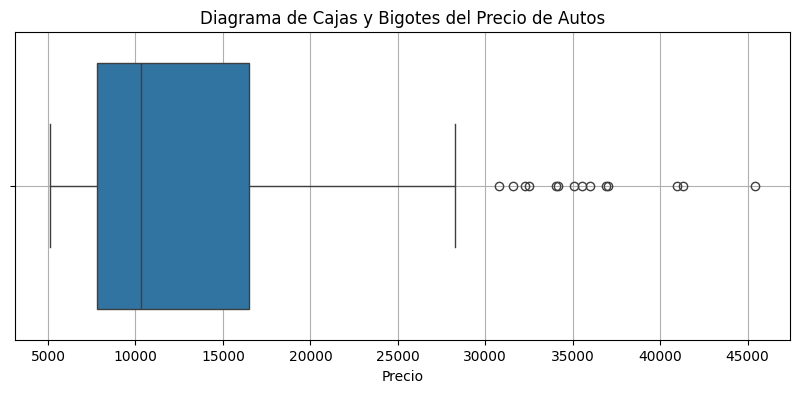

In [66]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["price"])

plt.title("Diagrama de Cajas y Bigotes del Precio de Autos")
plt.xlabel("Precio")
plt.grid(True)
plt.show()

### Interpretación

El diagrama muestra que la mayor parte de los precios se concentra en los rangos bajos y medios. También se observan varios valores atípicos correspondientes a vehículos con precios considerablemente superiores al resto.

El modelo obtuvo un RMSE aproximado de 3,031, lo que indica que las predicciones del precio presentan una desviación típica de aproximadamente 3,031 unidades monetarias respecto a los valores reales

El valor de **R² = 0.92** indica que el árbol de regresión permite explicar aproximadamente el **92% de la variación del precio** utilizando las variables predictoras seleccionadas.

## 6. Comparar precios reales vs. predichos

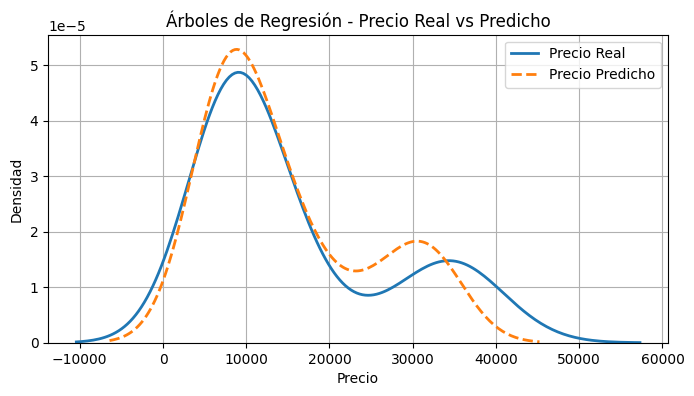

In [67]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title("Árboles de Regresión - Precio Real vs Predicho")
plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()

### Puntos clave del gráfico

Las distribuciones de los precios reales y predichos presentan una similitud considerable. El modelo logra representar la tendencia general de los precios, aunque existen diferencias entre ambas distribuciones.

El valor de **R² = 0.92** indica que el árbol de regresión captura una parte importante de la variabilidad del precio.

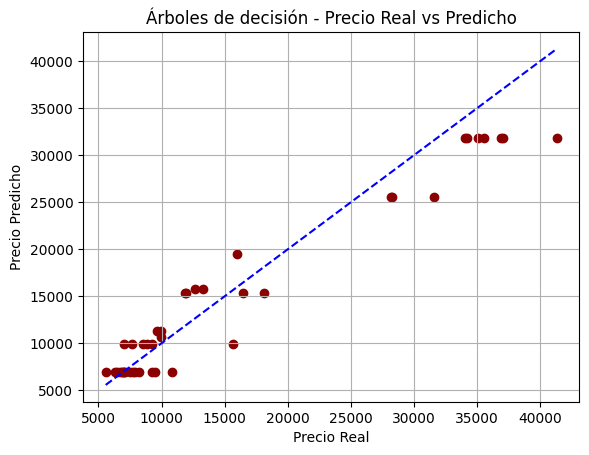

In [68]:
plt.scatter(y_test, y_pred_tree, color='darkred')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--'
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Árboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

### Interpretación

Los puntos cercanos a la línea diagonal representan predicciones con menor diferencia respecto al precio real.

En los vehículos de precios bajos y medios se observa una mayor cercanía entre los valores reales y predichos. En algunos vehículos de mayor precio existe una separación más considerable respecto a la línea ideal, lo que indica una mayor diferencia en la predicción.

En general, el modelo presenta un buen ajuste, aunque la precisión varía dependiendo del rango de precios.

## 7. Visualización del árbol de decisión

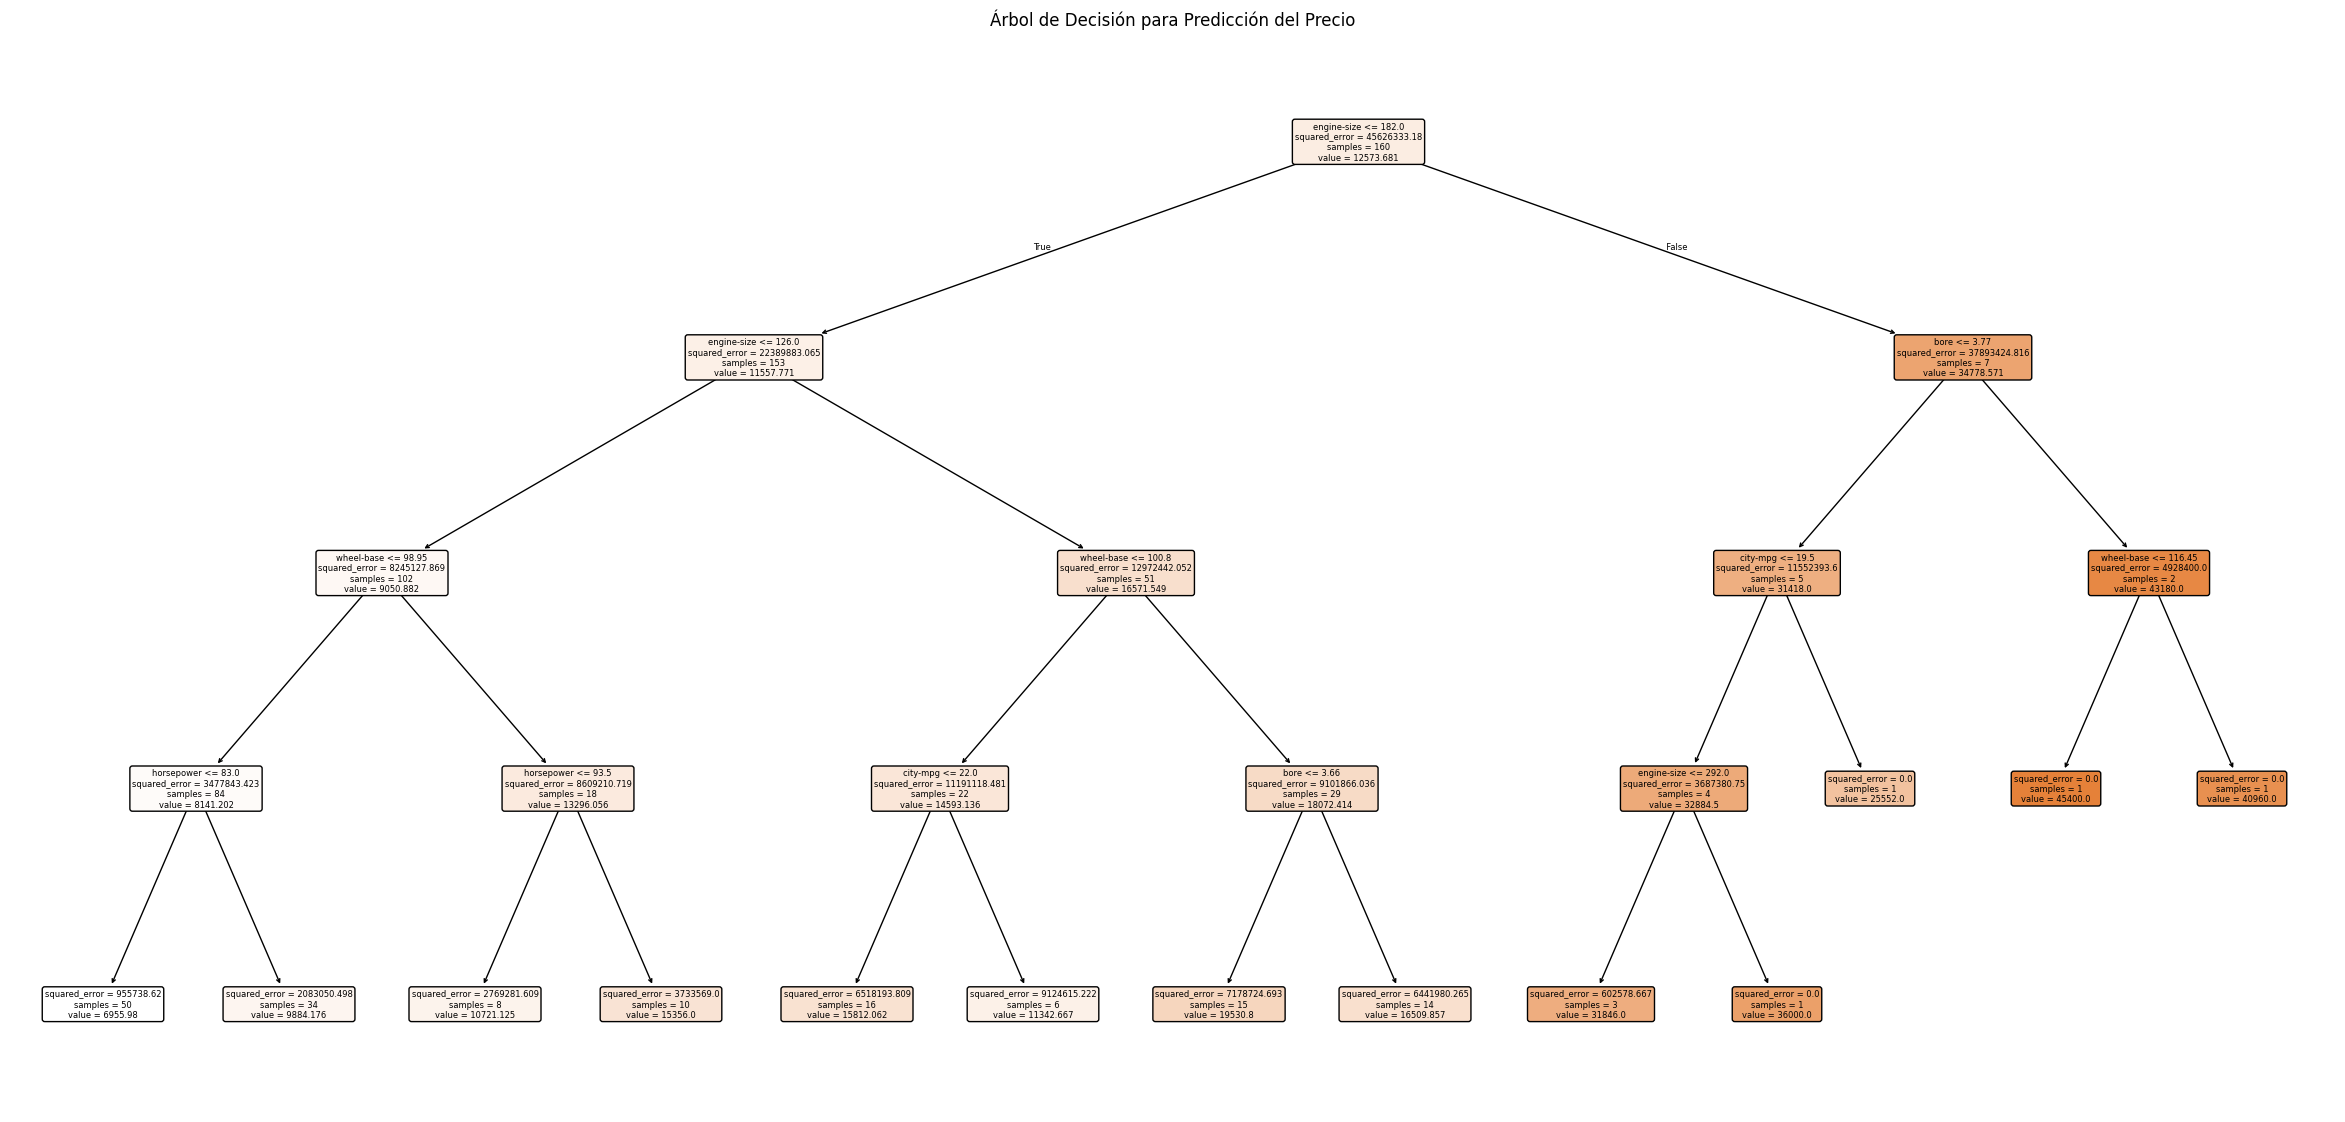

In [69]:
plt.figure(figsize=(30, 14))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

### Interpretación del árbol

El árbol divide los datos mediante reglas basadas en las variables predictoras para estimar el precio de los automóviles.

Cada nodo muestra la condición utilizada para realizar una división, el error del nodo, la cantidad de muestras y el valor estimado. Las ramas representan las decisiones que sigue el modelo hasta llegar a una predicción.

En las primeras divisiones se observa la importancia de características como el tamaño del motor (`engine-size`). Posteriormente se utilizan otras variables, como `wheel-base`, `horsepower`, `city-mpg` y `bore`, para realizar divisiones más específicas.

## 8. Ajuste de profundidad del árbol

In [70]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=9)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
rmse = np.sqrt(mse_tree)

print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 7896468.85
Coeficiente de determinación (R²): 0.94
Raíz del Error cuadrático medio (RMSE): 2810.07


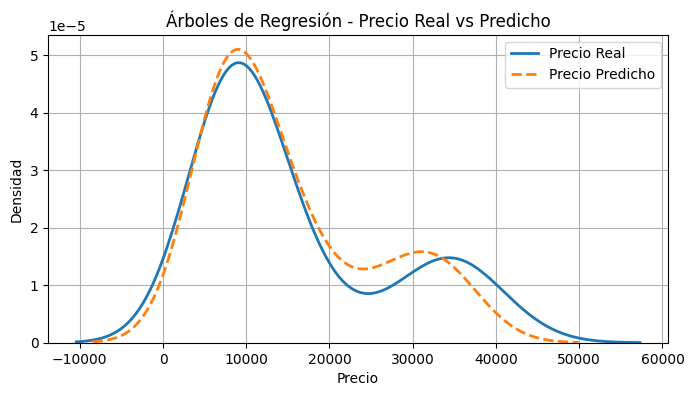

In [71]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title("Árboles de Regresión - Precio Real vs Predicho")
plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()

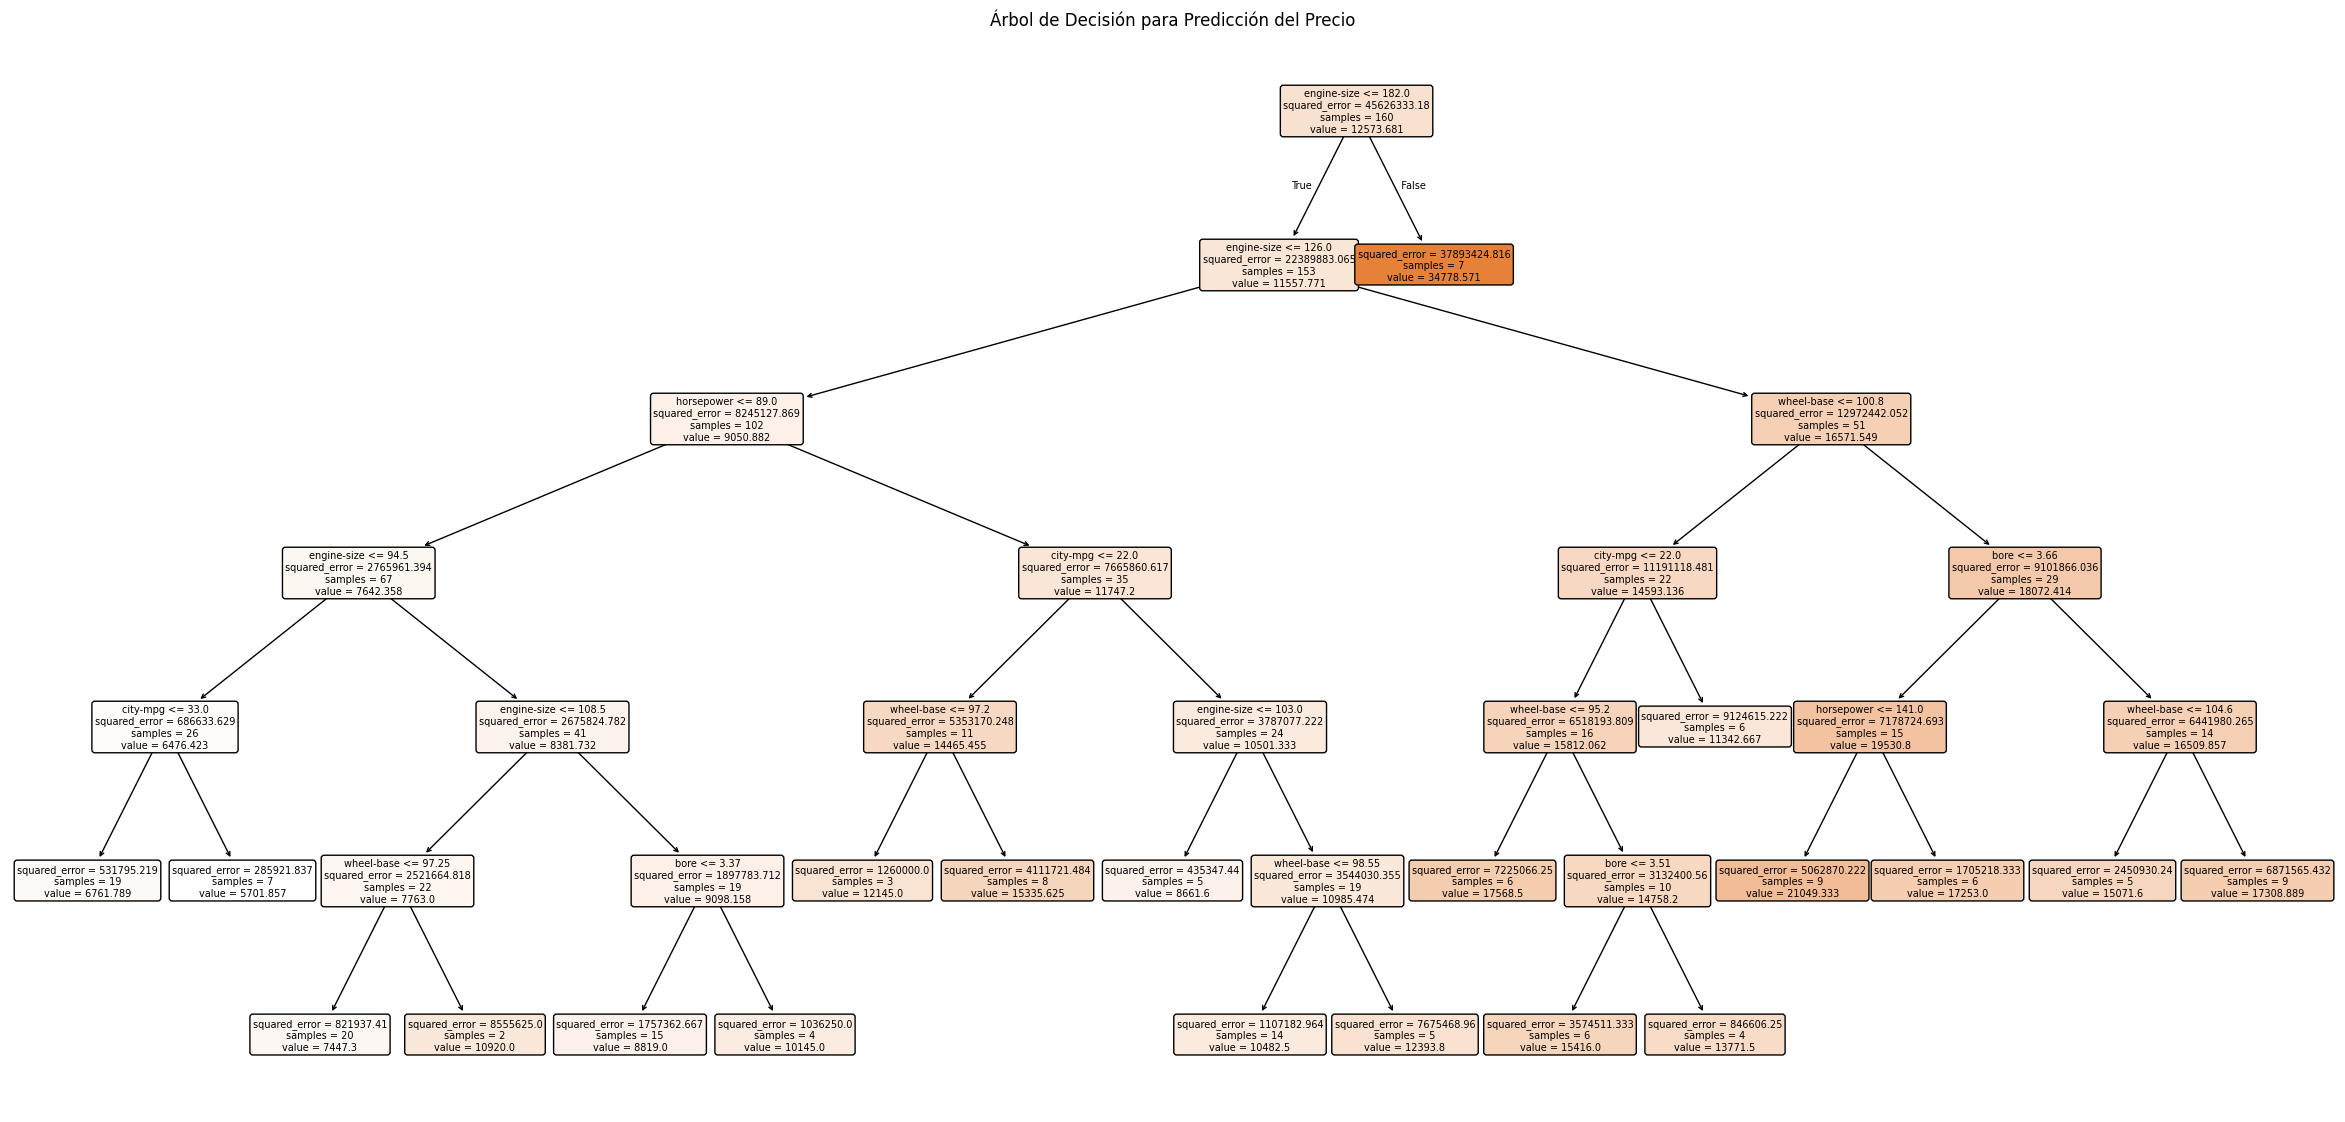

In [77]:
plt.figure(figsize=(30, 14))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

### Interpretación del ajuste de profundidad

Al aumentar la profundidad máxima del árbol a 9, el modelo obtuvo un R² de 0.94 y un RMSE aproximado de 2,810. En comparación con el árbol inicial, que obtuvo un R² de 0.92 y un RMSE aproximado de 3,031, se observa una mejora en el ajuste y una reducción del error de predicción.

Sin embargo, aumentar la profundidad también incrementa la complejidad del árbol, por lo que posteriormente se ajustan otros parámetros para controlar su crecimiento y evaluar si es posible mejorar su desempeño.

## 9. Ajuste de parámetros del árbol de decisión

In [73]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    max_leaf_nodes=20
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
rmse = np.sqrt(mse_tree)

print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 6207944.08
Coeficiente de determinación (R²): 0.95
Raíz del Error cuadrático medio (RMSE): 2491.57


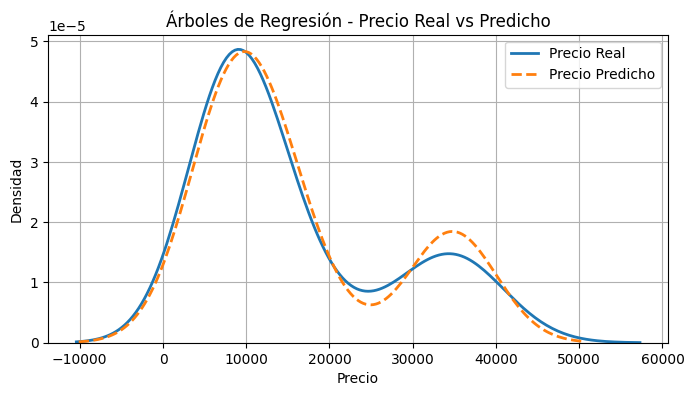

In [74]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title("Árboles de Regresión - Precio Real vs Predicho")
plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()
plt.show()

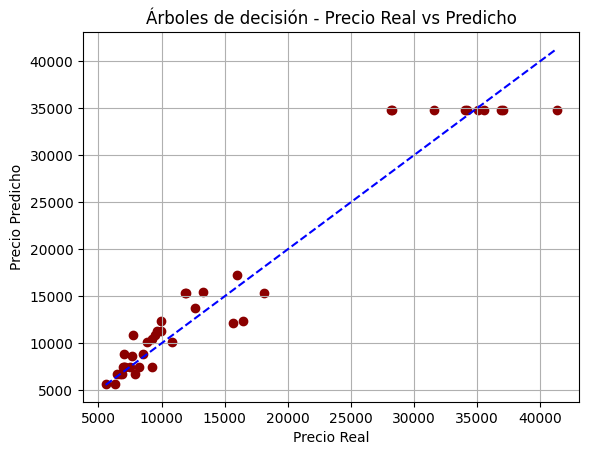

In [75]:
plt.scatter(y_test, y_pred_tree, color='darkred')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--'
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Árboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

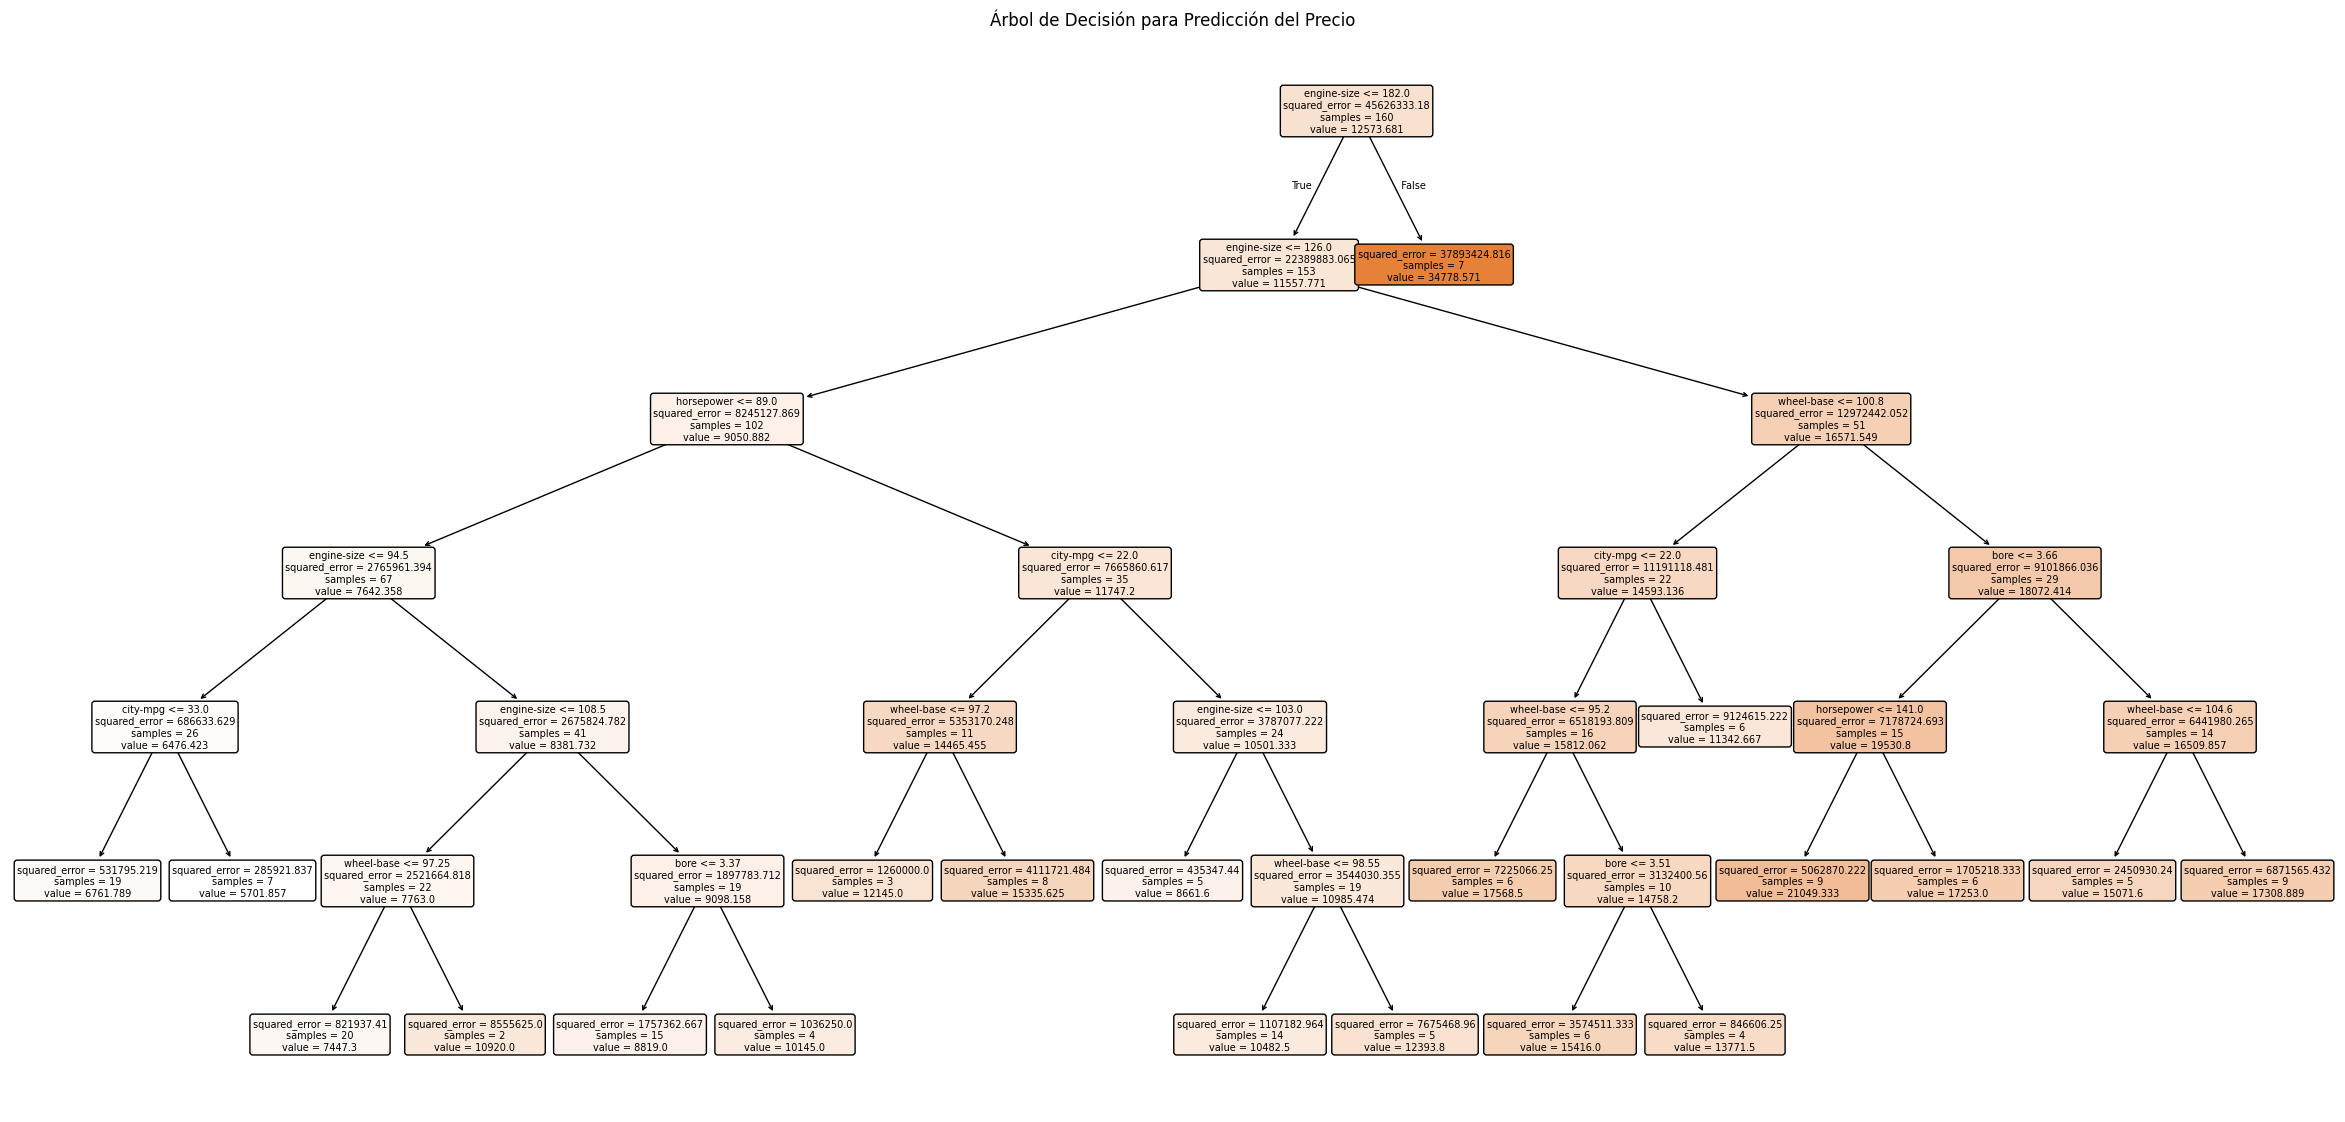

In [76]:
plt.figure(figsize=(30, 14))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

### Interpretación final

El ajuste de los parámetros del árbol permite modificar su complejidad y controlar la forma en que se realizan las divisiones.

Con la configuración final, el modelo obtiene un **R² cercano a 0.95**, indicando que logra explicar aproximadamente el **95% de la variación del precio**. Asimismo, el RMSE disminuye respecto al árbol inicial, mostrando una reducción en el error de predicción.

Los resultados muestran que el árbol de regresión puede representar relaciones más complejas entre las características de los automóviles y su precio.